# 08 - Feature Engineering V3

## Limpieza conservadora y transformación del dataset para Machine Learning

En la versión anterior de limpieza se aplicaron reglas muy estrictas que redujeron el dataset desde 1030 filas hasta 396 filas.  
Aunque esa limpieza eliminó valores extremos, también pudo haber quitado registros útiles para el aprendizaje del modelo.

En esta versión V3 se aplica una estrategia más conservadora:

- eliminar solo valores físicamente imposibles;
- conservar comportamientos operacionales extremos que podrían ser informativos;
- aplicar clipping en vez de eliminar muchos registros;
- recalcular variables derivadas;
- generar un nuevo dataset mejorado sin perder demasiada información.

El objetivo es mejorar la calidad de los datos sin destruir el tamaño del dataset.


# Objetivos del notebook

En este notebook busco:

- conservar la mayor cantidad posible de registros;
- eliminar solo errores evidentes;
- tratar outliers extremos mediante clipping;
- recalcular variables derivadas;
- crear nuevas variables con sentido logístico;
- generar un dataset `dataset_modelo_v3.csv`;
- dejar preparado el dataset para volver a entrenar modelos y comparar F1-score.


# 1. Configuración inicial

In [4]:
# Conexión con Kedro.
%load_ext kedro.ipython

# Librerías principales.
import os
import pandas as pd
import numpy as np

# Visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset base

Cargo el dataset integrado original generado por Kedro.


In [5]:
df = catalog.load("dataset_modelo")

print("Dimensiones iniciales:", df.shape)

df.head()


[05/13/26 15:14:49] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=6672713;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=6672714;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

Dimensiones iniciales: (1030, 31)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 3. Diagnóstico inicial

Reviso nuevamente las variables que presentaron problemas en el análisis anterior.


In [6]:
variables_revision = [
    "peso_kg",
    "volumen_m3",
    "distancia_km",
    "tiempo_estimado_hrs",
    "velocidad_promedio_km_h",
    "capacidad_kg",
    "capacidad_m3",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "km_recorridos",
    "tiene_incidencia"
]

df[variables_revision].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg,1030.0,10887.278544,40728.858673,-66657.5000,3802.350000,7558.600000,11245.375000,724190.000000
volumen_m3,1030.0,30.468417,16.887517,0.1100,16.527500,30.305000,45.090000,59.960000
distancia_km,1002.0,1302.530439,2467.810704,29.6000,507.200000,919.300000,1492.800000,18627.000000
tiempo_estimado_hrs,1002.0,12.299002,6.649828,0.9000,6.300000,12.200000,17.500000,23.700000
velocidad_promedio_km_h,1030.0,166.274662,272.076155,0.0000,39.925764,78.919355,155.914530,1766.555556
capacidad_kg,999.0,7589.589590,5918.089159,1000.0000,3000.000000,5000.000000,10000.000000,20000.000000
capacidad_m3,999.0,36.538739,20.258987,5.3000,18.500000,38.100000,49.200000,78.900000
uso_capacidad_kg,1030.0,3.465193,20.972171,-13.3315,0.420878,1.096690,2.426745,621.785000
uso_capacidad_m3,1030.0,1.243508,1.401316,0.0000,0.413542,0.809654,1.550257,10.871698
km_recorridos,999.0,227408.516517,135214.959340,13823.0000,110804.000000,224573.500000,341278.000000,478395.000000


## Análisis

El diagnóstico anterior mostró valores problemáticos, pero ahora separo dos conceptos:

- **valor imposible:** no tiene sentido físico y debe eliminarse o corregirse.
- **valor extremo:** puede ser raro, pero podría representar una situación logística real.

Esta diferencia es importante porque no todos los outliers deben eliminarse. Algunos podrían explicar justamente la aparición de incidencias.


# 4. Conteo de reglas problemáticas

Cuantifico nuevamente los casos que incumplen reglas lógicas o presentan valores extremos.


In [7]:
condiciones = {
    "peso_kg_menor_igual_cero": df["peso_kg"] <= 0,
    "peso_kg_extremo_mayor_40000": df["peso_kg"] > 40000,
    "distancia_km_menor_igual_cero": df["distancia_km"] <= 0,
    "distancia_km_extrema_mayor_4000": df["distancia_km"] > 4000,
    "tiempo_estimado_menor_igual_cero": df["tiempo_estimado_hrs"] <= 0,
    "velocidad_menor_igual_cero": df["velocidad_promedio_km_h"] <= 0,
    "velocidad_extrema_mayor_180": df["velocidad_promedio_km_h"] > 180,
    "uso_capacidad_kg_negativo": df["uso_capacidad_kg"] < 0,
    "uso_capacidad_kg_mayor_1_5": df["uso_capacidad_kg"] > 1.5,
    "uso_capacidad_m3_mayor_3": df["uso_capacidad_m3"] > 3
}

resumen = pd.DataFrame({
    "regla": condiciones.keys(),
    "cantidad": [cond.sum() for cond in condiciones.values()]
})

resumen


,regla,cantidad
0,peso_kg_menor_igual_cero,4
1,peso_kg_extremo_mayor_40000,10
2,distancia_km_menor_igual_cero,0
3,distancia_km_extrema_mayor_4000,19
4,tiempo_estimado_menor_igual_cero,0
5,velocidad_menor_igual_cero,28
6,velocidad_extrema_mayor_180,198
7,uso_capacidad_kg_negativo,4
8,uso_capacidad_kg_mayor_1_5,393
9,uso_capacidad_m3_mayor_3,86


## Análisis

En la limpieza V2 se eliminaron muchos registros por `uso_capacidad_kg > 1.5`.

En esta nueva versión, esa condición no se usará para borrar registros, porque una alta utilización de capacidad puede ser una señal relevante para predecir incidencias.

La eliminación se limitará a errores evidentes como pesos negativos, tiempos imposibles o velocidades no razonables.


# 5. Limpieza conservadora

Creo una copia del dataset y aplico solo reglas mínimas de eliminación.

A diferencia de la versión anterior, NO elimino registros solo porque tengan sobrecarga o uso de capacidad alto.


In [8]:
df_v3 = df.copy()

filas_antes = df_v3.shape[0]

# Eliminación conservadora: solo valores imposibles o muy poco razonables.
df_v3 = df_v3[
    (df_v3["peso_kg"] > 0) &
    (df_v3["distancia_km"] > 0) &
    (df_v3["tiempo_estimado_hrs"] > 0) &
    (df_v3["velocidad_promedio_km_h"] > 0)
].copy()

filas_despues = df_v3.shape[0]

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)
print("Porcentaje eliminado:", round(((filas_antes - filas_despues) / filas_antes) * 100, 2), "%")


Filas antes: 1030
Filas después: 998
Filas eliminadas: 32
Porcentaje eliminado: 3.11 %


## Análisis de limpieza conservadora

Esta limpieza debería eliminar muchas menos filas que la versión V2.

La idea es mantener la mayor cantidad de ejemplos posible para que el modelo tenga más información disponible durante el entrenamiento.


# 6. Tratamiento de extremos mediante clipping

En vez de eliminar registros extremos, se limitan los valores superiores a umbrales razonables.

Esto permite:

- conservar filas;
- reducir distorsión estadística;
- mantener señales operacionales útiles.


In [9]:
# Copia para preservar valores originales si se desean comparar.
df_v3["peso_kg_original"] = df_v3["peso_kg"]
df_v3["distancia_km_original"] = df_v3["distancia_km"]
df_v3["velocidad_promedio_km_h_original"] = df_v3["velocidad_promedio_km_h"]
df_v3["uso_capacidad_kg_original"] = df_v3["uso_capacidad_kg"]
df_v3["uso_capacidad_m3_original"] = df_v3["uso_capacidad_m3"]

# Clipping conservador.
df_v3["peso_kg"] = df_v3["peso_kg"].clip(upper=40000)
df_v3["distancia_km"] = df_v3["distancia_km"].clip(upper=4000)
df_v3["velocidad_promedio_km_h"] = df_v3["velocidad_promedio_km_h"].clip(upper=180)

# Para ratios, no elimino sobrecarga, solo limito valores extremadamente explosivos.
df_v3["uso_capacidad_kg"] = df_v3["uso_capacidad_kg"].clip(lower=0, upper=5)
df_v3["uso_capacidad_m3"] = df_v3["uso_capacidad_m3"].clip(lower=0, upper=5)

df_v3[[
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg",
    "uso_capacidad_m3"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg,998.0,7860.699900,5340.718864,13.600000,3835.475000,7558.600000,11283.750000,40000.0
distancia_km,998.0,1026.657415,674.021421,29.600000,507.200000,919.300000,1492.800000,4000.0
velocidad_promedio_km_h,998.0,92.736315,59.472952,2.943396,40.136842,79.422222,155.914530,180.0
uso_capacidad_kg,998.0,1.707254,1.638906,0.000000,0.442062,1.113280,2.460825,5.0
uso_capacidad_m3,998.0,1.192896,1.144612,0.000000,0.415988,0.813299,1.566036,5.0


## Análisis del clipping

El clipping no elimina registros, solo limita valores extremos.

Por ejemplo, si una velocidad aparece en 1700 km/h, no se elimina toda la fila, sino que se limita a un valor máximo definido.

Esto es más conservador que eliminar filas completas y ayuda a conservar ejemplos para entrenamiento.


# 7. Comparación antes vs después del clipping

In [10]:
variables_comparacion = [
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg",
    "uso_capacidad_m3"
]

comparacion = pd.concat(
    [
        df[variables_comparacion].describe().T.add_suffix("_original"),
        df_v3[variables_comparacion].describe().T.add_suffix("_v3")
    ],
    axis=1
)

comparacion


,count_original,mean_original,std_original,min_original,25%_original,50%_original,75%_original,max_original,count_v3,mean_v3,std_v3,min_v3,25%_v3,50%_v3,75%_v3,max_v3
peso_kg,1030.0,10887.278544,40728.858673,-66657.5000,3802.350000,7558.600000,11245.375000,724190.000000,998.0,7860.699900,5340.718864,13.600000,3835.475000,7558.600000,11283.750000,40000.0
distancia_km,1002.0,1302.530439,2467.810704,29.6000,507.200000,919.300000,1492.800000,18627.000000,998.0,1026.657415,674.021421,29.600000,507.200000,919.300000,1492.800000,4000.0
velocidad_promedio_km_h,1030.0,166.274662,272.076155,0.0000,39.925764,78.919355,155.914530,1766.555556,998.0,92.736315,59.472952,2.943396,40.136842,79.422222,155.914530,180.0
uso_capacidad_kg,1030.0,3.465193,20.972171,-13.3315,0.420878,1.096690,2.426745,621.785000,998.0,1.707254,1.638906,0.000000,0.442062,1.113280,2.460825,5.0
uso_capacidad_m3,1030.0,1.243508,1.401316,0.0000,0.413542,0.809654,1.550257,10.871698,998.0,1.192896,1.144612,0.000000,0.415988,0.813299,1.566036,5.0


# 8. Visualización antes y después

Comparo boxplots para observar si el clipping ayudó a controlar valores extremos.


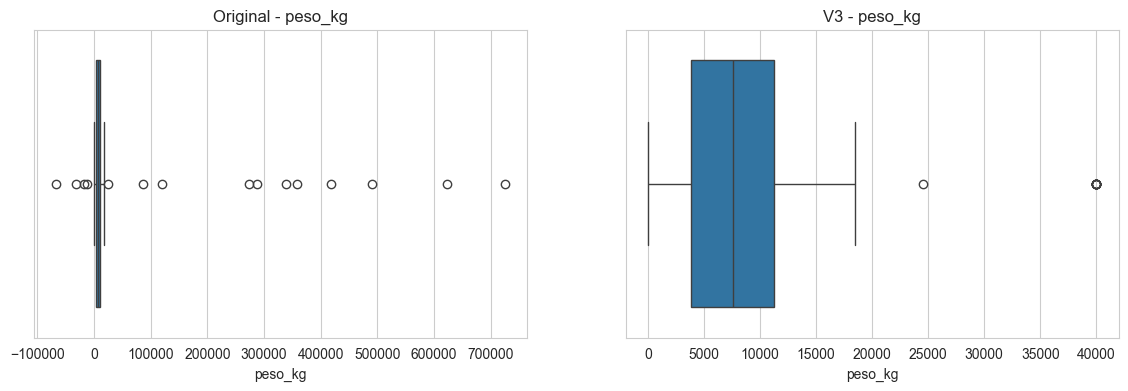

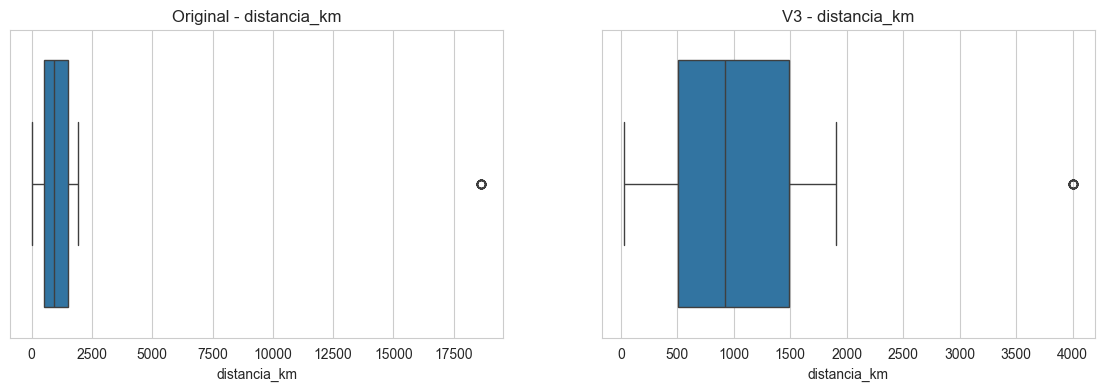

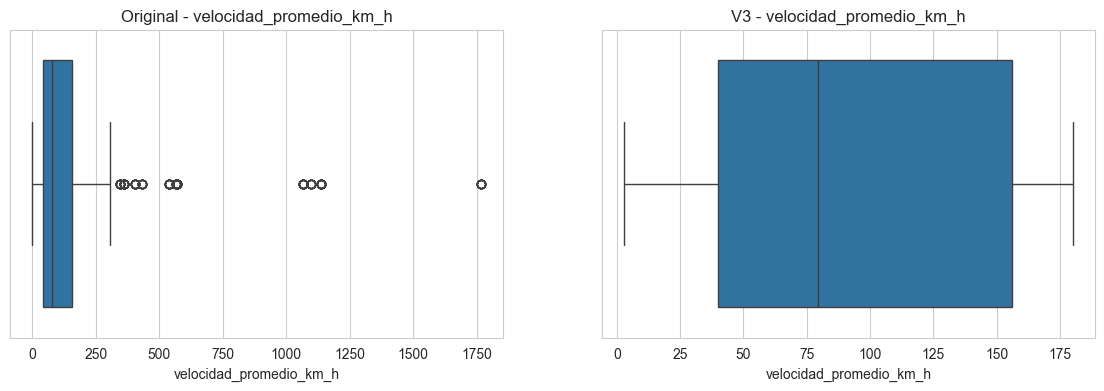

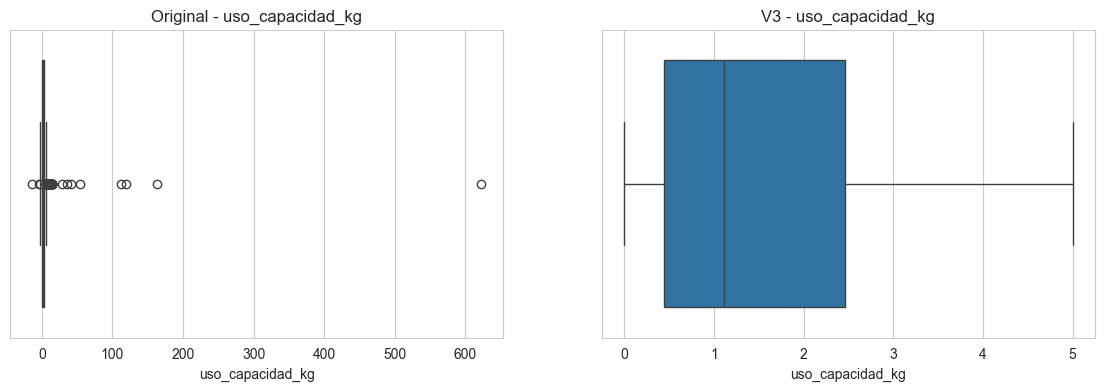

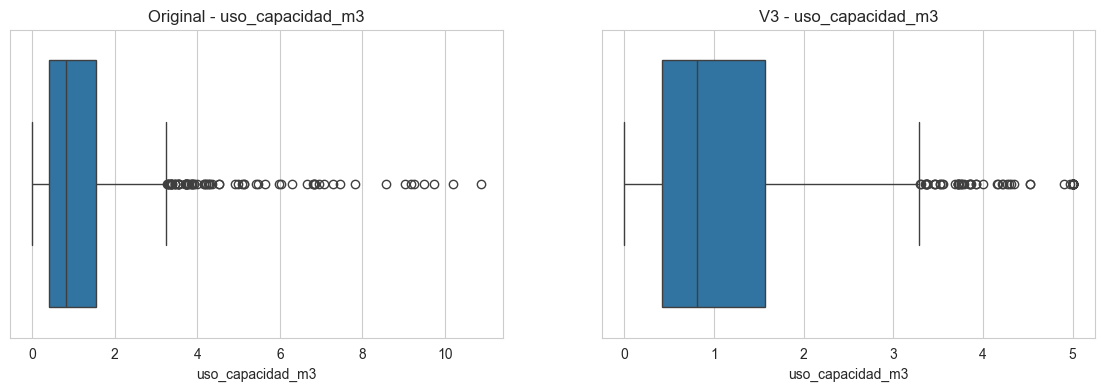

In [11]:
for col in variables_comparacion:
    fig, axes = plt.subplots(1, 2, figsize=(14,4))

    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f"Original - {col}")

    sns.boxplot(x=df_v3[col], ax=axes[1])
    axes[1].set_title(f"V3 - {col}")

    plt.show()


# 9. Revisión de la variable objetivo

Verifico si la limpieza conservadora mantiene una distribución similar del target `tiene_incidencia`.


In [12]:
print("Distribución original:")
print(df["tiene_incidencia"].value_counts())
print(df["tiene_incidencia"].value_counts(normalize=True) * 100)

print("\nDistribución V3:")
print(df_v3["tiene_incidencia"].value_counts())
print(df_v3["tiene_incidencia"].value_counts(normalize=True) * 100)


Distribución original:
tiene_incidencia
0.0    856
1.0    174
Name: count, dtype: int64
tiene_incidencia
0.0    83.106796
1.0    16.893204
Name: proportion, dtype: float64

Distribución V3:
tiene_incidencia
0.0    834
1.0    164
Name: count, dtype: int64
tiene_incidencia
0.0    83.567134
1.0    16.432866
Name: proportion, dtype: float64


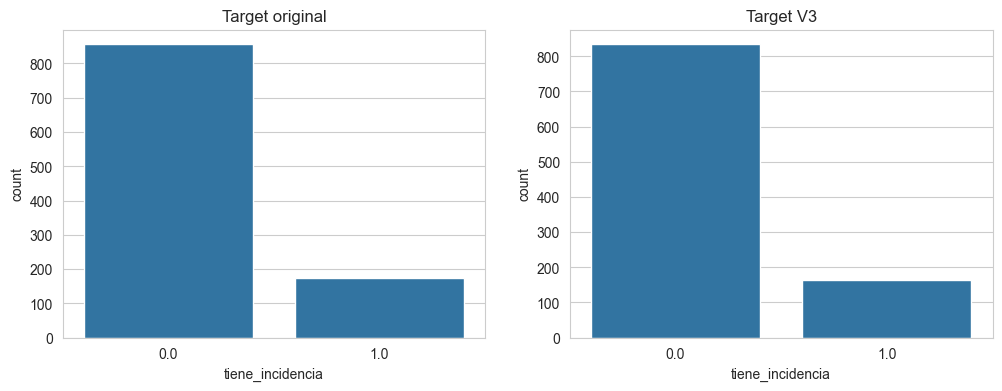

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(data=df, x="tiene_incidencia", ax=axes[0])
axes[0].set_title("Target original")

sns.countplot(data=df_v3, x="tiene_incidencia", ax=axes[1])
axes[1].set_title("Target V3")

plt.show()


## Análisis del target

Si la proporción de incidencias se mantiene similar, significa que la limpieza no eliminó desproporcionadamente la clase positiva.

Esto es clave para evitar empeorar el desbalance del problema.


# 10. Recalcular variables derivadas

Después del clipping, recalculo variables derivadas para que no se basen en valores extremos originales.


In [14]:
# Recalcular uso de capacidad si existen columnas base disponibles.
df_v3["uso_capacidad_kg_recalculado"] = (
    df_v3["peso_kg"] / df_v3["capacidad_kg"]
)

df_v3["uso_capacidad_m3_recalculado"] = (
    df_v3["volumen_m3"] / df_v3["capacidad_m3"]
)

# Limitar ratios recalculados para evitar infinitos/extremos.
df_v3["uso_capacidad_kg_recalculado"] = df_v3["uso_capacidad_kg_recalculado"].clip(lower=0, upper=5)
df_v3["uso_capacidad_m3_recalculado"] = df_v3["uso_capacidad_m3_recalculado"].clip(lower=0, upper=5)

df_v3[[
    "uso_capacidad_kg",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3",
    "uso_capacidad_m3_recalculado"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
uso_capacidad_kg,998.0,1.707254,1.638906,0.000000,0.442062,1.113280,2.460825,5.0
uso_capacidad_kg_recalculado,971.0,1.747518,1.626008,0.002410,0.498960,1.176100,2.510443,5.0
uso_capacidad_m3,998.0,1.192896,1.144612,0.000000,0.415988,0.813299,1.566036,5.0
uso_capacidad_m3_recalculado,971.0,1.226066,1.142757,0.001401,0.449641,0.836199,1.616188,5.0


## Análisis

Los ratios recalculados permiten tener variables más coherentes después de corregir valores extremos.

Mantengo tanto los ratios originales tratados como los recalculados, ya que luego los modelos podrán evaluar cuál aporta más información.


# 11. Feature Engineering V3

Creo variables derivadas con sentido logístico.


In [15]:
anio_referencia = 2026

df_v3["antiguedad_vehiculo"] = anio_referencia - df_v3["año_fabricacion"]

df_v3["densidad_carga"] = (
    df_v3["peso_kg"] /
    (df_v3["volumen_m3"] + 0.001)
)

df_v3["riesgo_operacional"] = (
    df_v3["distancia_km"] *
    df_v3["uso_capacidad_kg_recalculado"]
)

df_v3["riesgo_velocidad"] = (
    df_v3["distancia_km"] *
    df_v3["velocidad_promedio_km_h"]
)

df_v3["vehiculo_exigido"] = np.where(
    df_v3["uso_capacidad_kg_recalculado"] >= 0.90,
    1,
    0
)

df_v3["sobrecarga_kg"] = np.where(
    df_v3["uso_capacidad_kg_recalculado"] > 1,
    1,
    0
)

umbral_ruta_larga = df_v3["distancia_km"].quantile(0.75)

df_v3["ruta_larga"] = np.where(
    df_v3["distancia_km"] >= umbral_ruta_larga,
    1,
    0
)

df_v3["velocidad_alta"] = np.where(
    df_v3["velocidad_promedio_km_h"] >= 100,
    1,
    0
)

df_v3["vehiculo_riesgoso_estado"] = np.where(
    df_v3["estado_vehiculo"].isin(["en mantención", "fuera de servicio"]),
    1,
    0
)

df_v3["via_compleja"] = np.where(
    df_v3["tipo_via"].isin(["camino rural", "ruta nacional"]),
    1,
    0
)

print("Variables derivadas creadas correctamente.")


Variables derivadas creadas correctamente.


# 12. Transformaciones logarítmicas

Aplico `log1p` sobre variables positivas y sesgadas.

Antes de aplicar log, aseguro que no existan valores negativos.


In [16]:
variables_log = [
    "peso_kg",
    "distancia_km",
    "volumen_m3",
    "velocidad_promedio_km_h",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "km_recorridos"
]

for col in variables_log:
    nueva_col = col + "_log"
    df_v3[nueva_col] = np.log1p(df_v3[col].clip(lower=0))

df_v3[[col + "_log" for col in variables_log]].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg_log,998.0,8.655609,0.986986,2.681022,8.252287,8.930574,9.331208,10.596660
distancia_km_log,998.0,6.654640,0.897665,3.421000,6.230875,6.824700,7.309078,8.294300
volumen_m3_log,998.0,3.210752,0.823222,0.104360,2.865339,3.443778,3.830596,4.110218
velocidad_promedio_km_h_log,998.0,4.244859,0.890656,1.372042,3.716904,4.387291,5.055701,5.198497
densidad_carga_log,998.0,5.534815,1.366099,0.435351,4.880377,5.521158,6.147818,11.303995
riesgo_operacional_log,971.0,6.656960,1.535510,0.304507,5.855931,6.831116,7.732349,9.903538
riesgo_velocidad_log,998.0,10.871917,1.735348,4.530813,10.322156,11.179139,12.167626,13.487008
km_recorridos_log,971.0,12.071901,0.835071,9.534161,11.615527,12.321963,12.740456,13.078194


# 13. Revisión de nulos e infinitos

Verifico que las transformaciones no hayan creado valores infinitos o errores.


In [17]:
nulos_v3 = df_v3.isnull().sum().sort_values(ascending=False)

print("Columnas con nulos:")
display(nulos_v3[nulos_v3 > 0])

numericas_v3 = df_v3.select_dtypes(include=np.number)
infinitos_v3 = np.isinf(numericas_v3).sum()

print("\nColumnas con infinitos:")
display(infinitos_v3[infinitos_v3 > 0])


Columnas con nulos:



fecha_envio                     537
fecha_entrega                   535
capacidad_m3                     27
capacidad_kg                     27
estado_vehiculo                  27
km_recorridos                    27
placa                            27
año_fabricacion                  27
tipo                             27
uso_capacidad_m3_recalculado     27
riesgo_operacional_log           27
km_recorridos_log                27
riesgo_operacional               27
antiguedad_vehiculo              27
uso_capacidad_kg_recalculado     27
dtype: int64


Columnas con infinitos:


Series([], dtype: int64)

# 14. Variables recomendadas para modelado V3

Defino una lista de variables candidatas para volver a entrenar el modelo de `tiene_incidencia`.


In [18]:
variables_modelo_v3 = [
    # Variables originales tratadas
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",

    # Ratios tratados y recalculados
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",

    # Variables derivadas
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",

    # Logarítmicas
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_operacional_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

objetivo = "tiene_incidencia"

print("Cantidad de variables V3:", len(variables_modelo_v3))


Cantidad de variables V3: 34


## Nota sobre fuga de información

No incluyo:

- `cantidad_incidencias`;
- `costo_total_incidencias`;
- `tipo_incidencia_principal`.

Estas columnas están directamente relacionadas con la ocurrencia de incidencias y podrían generar fuga de información.


# 15. Revisión final del dataset V3

In [19]:
print("Dataset original:", df.shape)
print("Dataset V3:", df_v3.shape)

print("\nDistribución final del target:")
print(df_v3["tiene_incidencia"].value_counts())
print(df_v3["tiene_incidencia"].value_counts(normalize=True) * 100)

df_v3[variables_modelo_v3 + [objetivo]].head()


Dataset original: (1030, 31)
Dataset V3: (998, 56)

Distribución final del target:
tiene_incidencia
0.0    834
1.0    164
Name: count, dtype: int64
tiene_incidencia
0.0    83.567134
1.0    16.432866
Name: proportion, dtype: float64


,distancia_km,tiempo_estimado_hrs,peso_kg,volumen_m3,capacidad_kg,capacidad_m3,velocidad_promedio_km_h,km_recorridos,tipo_via,tipo_carga,estado_vehiculo,tipo,uso_capacidad_kg,uso_capacidad_m3,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log,tiene_incidencia
0,919.3,16.7,12675.8,28.48,10000.0,20.5,55.047904,17043.0,urbana,peligrosa,en mantención,camión,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554,0.0
1,679.6,18.4,13.6,24.93,1000.0,22.1,36.934783,88004.0,urbana,peligrosa,operativo,van,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149,0.0
2,468.4,5.2,2536.0,50.55,20000.0,38.9,90.076923,243705.0,ruta nacional,refrigerada,en mantención,furgón,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718,0.0
3,1642.4,18.9,466.0,13.88,1000.0,25.3,86.899471,224573.5,ruta nacional,peligrosa,operativo,van,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963,1.0
4,1556.6,17.9,4928.9,0.44,5000.0,49.1,86.960894,138259.0,urbana,refrigerada,operativo,camioneta,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891,0.0


# 16. Guardado del dataset V3

Guardo el dataset en `data/05_model_input/dataset_modelo_v3.csv`.


In [20]:
os.makedirs("data/05_model_input", exist_ok=True)

ruta_salida = "data/05_model_input/dataset_modelo_v3.csv"

df_v3.to_csv(ruta_salida, index=False, encoding="utf-8")

print("Dataset V3 guardado en:")
print(ruta_salida)


Dataset V3 guardado en:
data/05_model_input/dataset_modelo_v3.csv


# 17. Conclusiones finales

En esta versión V3 se aplicó una limpieza más conservadora que la V2.

La principal diferencia es que no se eliminaron masivamente registros por valores extremos o sobrecarga.  
En su lugar, se usó clipping para controlar valores muy altos sin perder filas.

Este enfoque permite conservar más información y mantener posibles señales útiles para predecir incidencias.

La siguiente etapa será reentrenar los modelos con `dataset_modelo_v3.csv` y comparar:

- dataset original;
- dataset V2;
- dataset V3.

El objetivo será verificar si el F1-score mejora sin sacrificar demasiados datos.
